2026-01-07 17-25-44
Outputs will be written to: results/run_2026-01-07 17-25-44
Saved a copy of the config : results/run_2026-01-07 17-25-44/config_copy.yaml
Inputs shape: (50, 8)
Outputs shape: (50,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output   source
49     0.259971     0.073653     0.072949     0.080030     1.111013     0.138991     0.251892     0.458765  9.742257  week-10
48     0.150000     0.150000     0.050000     0.050000     0.350000     0.750000     0.500000     0.850000  9.615800   week-9
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759   week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482     file
47     0.045306     0.045319     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.588003   week-8
42     0.043751 

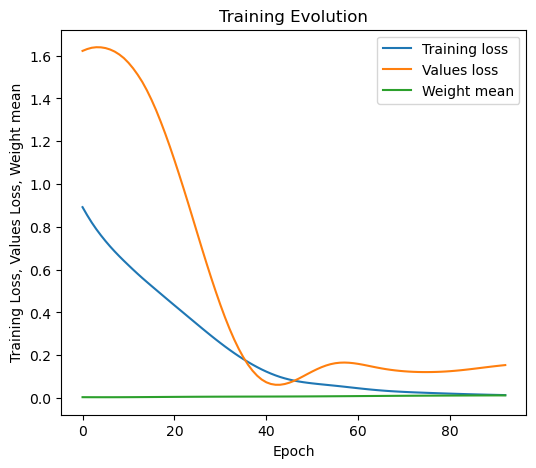

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (400000, 8)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 7
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.02341405, 0.19865142, 0.06619681, 0.99999705, 0.66828566,
       1.07335653, 0.05461937, 1.0839747 ]), 'score': 0.6270395269418789, 'dim': 8, 'predicted_y': 10.220021, 'improvement_over_input_model': 0.35938358, 'distance_to_best_input': 1.2421739469224369}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.02341405, 0.19865142, 0.06619681, 0.99999705, 0.66828566,
       1.07335653, 0.05461937, 1.0839747 ]), 'score': 0.5606934965544672, 'dim': 8, 'predicted_y': 10.220021, 'improvement_over_input_model': 0.35938358, 'distance_to_best_input': 1.2421739469224369}
{'method': 'EI', 'xi': 0.

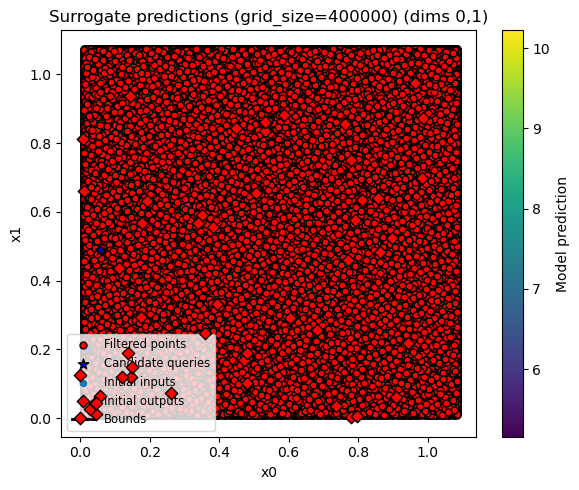

Saved dataframe to: results/run_2026-01-07 17-25-44/df_grid_400000_stride6_None_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.05624394, 0.48813162, 0.01628765, 0.8665624 , 1.2072488 ,
       0.26346672, 0.04754139, 1.01011248]), 'score': 4.751097371129332, 'dim': 8, 'predicted_y': 9.996546, 'improvement_over_input_model': 0.13590813, 'distance_to_best_input': 1.2059669196395617, 'best_input_x': array([0.      , 0.      , 0.      , 0.845416, 0.918723, 0.589616,
       0.      , 0.      ]), 'best_input_pred': 9.860638}
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output   source  output-scaled
0      0.259971     0.073653     0.072949     0.080030     1.111013     0.138991     0.251892     0.458765  9.742257  week-10      10.000000
1      0.150000     0.150000     0.050000     0.050000     0.350000     0.750000     0.500000     0.850000  9.615800   week-9       9.870197


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))